In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [2]:
pd.set_option("display.max_columns", None)

In [3]:
import warnings
warnings.filterwarnings("ignore")

#### data processing

In [4]:
data_path = "../data/"
output_path = "../output/"

In [5]:
data = pd.read_csv(data_path + "diabetes_130_full.csv", low_memory = False)

##### mapping

In [6]:
### Assign relevant item mapping to id from csv

IDs_mapping = pd.read_csv(data_path + "IDS_mapping.csv")

admission_id_mapping = IDs_mapping.iloc[:8, :]
admission_id_mapping['admission_type_id'] = admission_id_mapping['admission_type_id'].astype(int)
admission_id_mapping = admission_id_mapping.set_index('admission_type_id')['description'].to_dict()

discharge_id_mapping = IDs_mapping.iloc[10:40, :]
discharge_id_mapping['admission_type_id'] = discharge_id_mapping['admission_type_id'].astype(int)
discharge_id_mapping = discharge_id_mapping.set_index('admission_type_id')['description'].to_dict()

admission_source_id_mapping = IDs_mapping.iloc[42:, :]
admission_source_id_mapping['admission_type_id'] = admission_source_id_mapping['admission_type_id'].astype(int)
admission_source_id_mapping = admission_source_id_mapping.set_index('admission_type_id')['description'].to_dict()

data['admission_type_id'] = data['admission_type_id'].map(admission_id_mapping)
data['discharge_disposition_id'] = data['discharge_disposition_id'].map(discharge_id_mapping)
data['admission_source_id'] = data['admission_source_id'].map(admission_source_id_mapping)

In [7]:
def map_diag_category(code):
    """
    Map ICD-9 diagnosis codes to broad disease categories.
    Returns 'Unknown' for missing or unrecognized codes.
    Based on wikipedia: https://en.wikipedia.org/wiki/List_of_ICD-9_codes
    """
    try:
        code = float(str(code).split('.')[0])
    except:
        if code == "?":
            return "Other / Unknown"
        elif code.startswith("E"):
            return "External Injury"
        elif code.startswith("V"):
            return "Supplemental classification"

    if 1 <= code <= 139:
        return 'Infectious & Parasitic'
    elif 140 <= code <= 239:
        return 'Neoplasms'
    elif 249 <= code < 251:
        return "Diabetes mellitus"
    elif 240 <= code <= 279:
        return 'Endocrine / Metabolic / Immunity'
    elif 280 <= code <= 289:
        return 'Blood & Blood-forming Organs'
    elif 290 <= code <= 319:
        return 'Mental Disorders'
    elif 320 <= code <= 389:
        return 'Nervous System'
    elif 390 <= code <= 459:
        return 'Circulatory System'
    elif 460 <= code <= 519:
        return 'Respiratory System'
    elif 520 <= code <= 579:
        return 'Digestive System'
    elif 580 <= code <= 629:
        return 'Genitourinary System'
    elif 630 <= code <= 679:
        return 'Pregnancy / Childbirth'
    elif 680 <= code <= 709:
        return 'Skin & Subcutaneous Tissue'
    elif 710 <= code <= 739:
        return 'Musculoskeletal System'
    elif 740 <= code <= 759:
        return 'Congenital Anomalies'
    elif 760 <= code <= 779:
        return 'Perinatal Conditions'
    elif 780 <= code <= 799:
        return 'Symptoms / Ill-defined Conditions'
    elif 800 <= code <= 999:
        return 'Injury & Poisoning'
    else:
        return 'Other / Unknown'

# Apply mapping to diagnosis columns
data['diag_1_category'] = data['diag_1'].apply(map_diag_category)

In [8]:
# Fill NaN and ensure lowercase strings
data['discharge_disposition_category'] = (
    data['discharge_disposition_id']
    .fillna('unknown')
    .astype(str)
    .str.lower()
)

conditions = [
    data['discharge_disposition_id'].str.lower().str.contains('home', na=False),
    data['discharge_disposition_id'].str.lower().str.contains('hospice', na=False),
    data['discharge_disposition_id'].str.lower().str.contains('hospital|rehab|swing bed|snf|icf|nursing|psychiatric|federal', na=False),
    data['discharge_disposition_id'].str.lower().str.contains('ama|admitted|inpatient|still patient', na=False),
    data['discharge_disposition_id'].str.lower().str.contains('outpatient', na=False),
]

choices = [
    'home',
    'hospice',
    'hospital / facility',
    'inpatient',
    'outpatient'
]

# Apply replacement safely
data['discharge_disposition_category'] = np.select(conditions, choices, default='other')

print(data['discharge_disposition_category'].value_counts())

discharge_disposition_category
home                   73651
hospital / facility    19584
other                   6322
inpatient               1810
hospice                  374
outpatient                25
Name: count, dtype: int64


##### Feature engineering

In [9]:
#Total procedures
data['total_procedures'] = (
    data['num_lab_procedures'] + data['num_procedures'] + data['num_medications']
)

#Ratio features
data['lab_med_ratio'] = data['num_lab_procedures'] / (data['num_medications'] + 1)

In [10]:
data.drop(columns = ['Unnamed: 0'], axis = 1, inplace = True)

In [11]:
## drop repeated encounters, only keep the first. 

data.sort_values(by = ['encounter_id'], inplace = True)
data = data.drop_duplicates(subset='patient_nbr', keep='first')      

In [12]:
data = data[data['gender'].isin(['Female', 'Male'])]  # drop 3 rows, small missing

In [13]:
data = data[~data['discharge_disposition_id'].str.lower().str.contains('expired', na=False)]  # patient who are expired, unable to get readmission according to the data.

In [14]:
data.shape

(70431, 54)

### Features Removal

##### Remove features with 75% missing, unless the missing refer to 'Not Taken' such as Test Results

In [15]:
# Missing Analysis (% Missing)

missing_results = data.isnull().sum() / len(data)

print("\nVariables with any missing values (descending)")
missing_results[missing_results > 0.75].sort_values(ascending = False)


Variables with any missing values (descending)


weight           0.960046
max_glu_serum    0.951939
A1Cresult        0.817154
dtype: float64

In [16]:
data.drop(columns = ['weight'], axis = 1, inplace = True)

We will keep the <strong>max_glu_serum</strong> and <strong>A1Cresult</strong> as these are test results -- missing just refer to patients who did not take the test. <br>This itself carry valuable information in the context of diabetic readmission

##### Remove features with no inherent relationship to diabetic readmission

In [17]:
data.drop(columns = ['admission_source_id', 
                     'payer_code', 
                     'medical_specialty',
                     'encounter_id', 
                     'patient_nbr'], axis = 1, inplace = True)

##### Remove features with low cardinality (i.e., >= 95% same value)

In [18]:
threshold = 0.95  # 95%

unique_ratio = data.nunique() / len(data)
dominant_ratio = data.apply(lambda col: col.value_counts(normalize=True).iloc[0])
low_variance_cols = dominant_ratio[dominant_ratio >= threshold].index.tolist()
print("Low-variance columns (≥95% same value):")
print(low_variance_cols)

Low-variance columns (≥95% same value):
['repaglinide', 'nateglinide', 'chlorpropamide', 'acetohexamide', 'tolbutamide', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


In [19]:
data.drop(columns = low_variance_cols, axis = 1, inplace = True)

In [20]:
mapping = {'NO': 0, '>30': 0, '<30': 1}
data['readmitted_binary'] = data['readmitted'].map(mapping)   # predicting short term readmission risk

In [21]:
data.drop(columns = ['readmitted'], axis = 1, inplace = True)

#### start

In [22]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

### Single Factor Analysis (WoE and IV) only on the Train to avoid Data Leakage

##### Categorical Variables

In [24]:
Categorical_var = X_train.select_dtypes(include='object').columns.tolist()
Categorical_var = [col for col in Categorical_var if col != 'readmitted']
print("Categorical columns:\n")
print(Categorical_var)

Categorical columns:

['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed', 'diag_1_category', 'discharge_disposition_category']


In [25]:
def woe_discrete(X, y, categorical_var):
    # Combine X and y temporarily inside the function
    df = X.copy()
    df['Bad'] = y.values  # y must be aligned index-wise with X

    WoE_results = pd.DataFrame()
    WoE_results[categorical_var] = df[categorical_var].astype(str).fillna('Missing')
    WoE_results['Bad'] = df['Bad']

    # Count and mean (bad rate)
    Count = WoE_results.groupby(categorical_var).count().reset_index()
    Mean = WoE_results.groupby(categorical_var).mean().reset_index()

    result = pd.concat([Count, Mean], axis=1).iloc[:, [0, 1, 3]]
    result.columns = [categorical_var, 'n_obs', 'prop_bad']

    # Compute stats
    result['prop_good'] = 1 - result['prop_bad']
    result['n_bad'] = result['prop_bad'] * result['n_obs']
    result['n_good'] = result['prop_good'] * result['n_obs']
    result['prop_n_bad'] = result['n_bad'] / result['n_bad'].sum()
    result['prop_n_good'] = result['n_good'] / result['n_good'].sum()

    # WoE & IV
    result['WoE'] = np.log((result['prop_n_good'] + 1e-10) / (result['prop_n_bad'] + 1e-10))
    result['%Good - %Bad'] = result['prop_n_good'] - result['prop_n_bad']
    result['IV'] = result['WoE'] * result['%Good - %Bad']
    result['IV'] = result['IV'].sum()
    result['prop_total'] = result['n_obs'] / result['n_obs'].sum()

    # Sort bins (numerically if possible)
    try:
        result[categorical_var] = result[categorical_var].astype(float)
        result.sort_values(by=categorical_var, inplace=True)
    except ValueError:
        result.sort_values(by=categorical_var, inplace=True)

    result.reset_index(drop=True, inplace=True)
    return result

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()                               

def plot_by_woe(df, rotation_of_x_axis_labels = 0):
    x = np.array(df.iloc[:, 0].apply(str))            
    y = df['WoE']
    plt.figure(figsize=(18, 6))
    plt.plot(x, y, marker = 'o', linestyle = '--', color = 'k')
    plt.xlabel(df.columns[0])
    plt.ylabel('Weight of Evidence')
    plt.title(str('Weight of Evidence by ' + df.columns[0]))
    plt.xticks(rotation = rotation_of_x_axis_labels)

In [27]:
iv_dict = {}

for var in Categorical_var:
    result_df = woe_discrete(X_train, y_train, var)
    iv_value = result_df['IV'].iloc[0] 
    iv_dict[var] = iv_value

iv_dict = dict(sorted(iv_dict.items(), key=lambda x: x[1], reverse=True))

for k, v in iv_dict.items():
    print(f"{k}: {v:.4f}")

diag_1: 0.7425
diag_3: 0.6386
diag_2: 0.6208
discharge_disposition_id: 0.1846
discharge_disposition_category: 0.1198
age: 0.0296
diag_1_category: 0.0293
diabetesMed: 0.0167
insulin: 0.0116
admission_type_id: 0.0080
race: 0.0044
change: 0.0038
glipizide: 0.0030
max_glu_serum: 0.0014
metformin: 0.0013
glimepiride: 0.0009
rosiglitazone: 0.0007
pioglitazone: 0.0006
A1Cresult: 0.0006
glyburide: 0.0004
gender: 0.0003


In [28]:
#### keep age (ordinal), 
#### discharge_disposition_id_category, diag_1_category (categorical)

### Ordinal Categorical

### Age

In [29]:
woe_discrete(X_train, y_train, 'age')

,age,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,[0-10),99,0.030303,0.969697,3.0,96.0,0.000681,0.002138,1.144127,0.001457,0.029559,0.002008
1,[10-20),381,0.052493,0.947507,20.0,361.0,0.004540,0.008041,0.571537,0.003501,0.029559,0.007728
2,[20-30),803,0.069738,0.930262,56.0,747.0,0.012713,0.016638,0.269105,0.003926,0.029559,0.016288
3,[30-40),1873,0.069407,0.930593,130.0,1743.0,0.029512,0.038823,0.274220,0.009311,0.029559,0.037991
4,[40-50),4821,0.075296,0.924704,363.0,4458.0,0.082406,0.099296,0.186444,0.016890,0.029559,0.097787
5,[50-60),8576,0.072994,0.927006,626.0,7950.0,0.142111,0.177076,0.219968,0.034965,0.029559,0.173952
6,[60-70),11072,0.088602,0.911398,981.0,10091.0,0.222701,0.224764,0.009218,0.002062,0.029559,0.224580
7,[70-80),12469,0.102494,0.897506,1278.0,11191.0,0.290125,0.249265,-0.151795,-0.040860,0.029559,0.252916
8,[80-90),7960,0.104397,0.895603,831.0,7129.0,0.188649,0.158789,-0.172312,-0.029860,0.029559,0.161457
9,[90-100),1247,0.093825,0.906175,117.0,1130.0,0.026561,0.025169,-0.053809,-0.001391,0.029559,0.025294


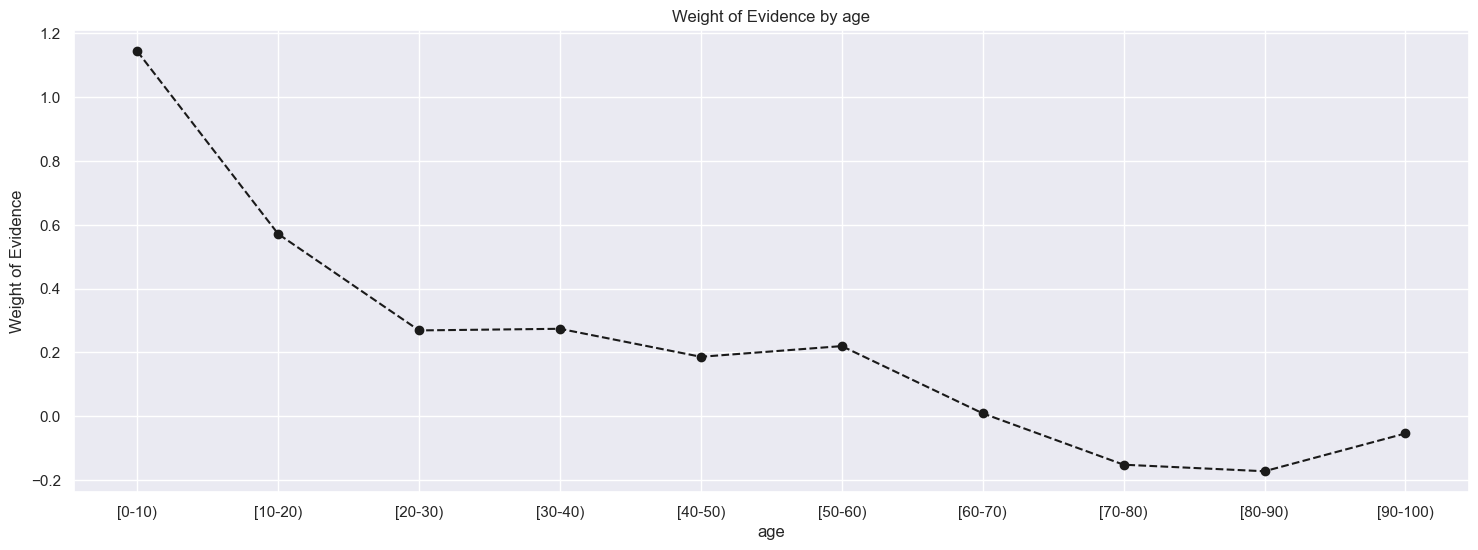

In [30]:
plot_by_woe(woe_discrete(X_train, y_train, 'age'))

In [31]:
age_order = [
    '[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
    '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)'
]

# Create a mapping dictionary: bin → ordinal number
age_mapping = {age: i+1 for i, age in enumerate(age_order)}

# Apply the mapping
X_train['age_encoded'] = X_train['age'].map(age_mapping)
print(X_train[['age', 'age_encoded']])        # do the same for Test set later! exactly same mapping as Train

           age  age_encoded
15796  [70-80)            8
91253  [30-40)            4
3377   [70-80)            8
16822  [60-70)            7
57752  [60-70)            7
...        ...          ...
819    [40-50)            5
31852  [40-50)            5
92538  [60-70)            7
45895  [70-80)            8
60652  [60-70)            7

[49301 rows x 2 columns]


## Nominal Categorical

### Discharge disposition

In [32]:
X_train = pd.get_dummies(X_train, columns=['discharge_disposition_category'], drop_first=True)

In [33]:
iv_dict = {}

for var in [col for col in X_train.columns if 'discharge_disposition_category_' in col]:
    result_df = woe_discrete(X_train, y_train, var)
    iv_value = result_df['IV'].iloc[0]
    iv_dict[var] = iv_value

# Sort IV values descending
iv_dict = dict(sorted(iv_dict.items(), key=lambda x: x[1], reverse=True))

# Display results
for k, v in iv_dict.items():
    print(f"{k}: {v:.4f}")

discharge_disposition_category_hospital / facility: 0.0950
discharge_disposition_category_inpatient: 0.0107
discharge_disposition_category_outpatient: 0.0033
discharge_disposition_category_hospice: 0.0023
discharge_disposition_category_other: 0.0001


In [34]:
X_train.drop(columns = ['discharge_disposition_category_inpatient', 
                   'discharge_disposition_category_outpatient',
                   'discharge_disposition_category_hospice',
                   'discharge_disposition_category_other'],
                   axis = 1, inplace = True)

## do the same for Test set later, exactly the same!

### diag_1_category

In [35]:
X_train = pd.get_dummies(X_train, columns=['diag_1_category'], drop_first=True)

In [36]:
iv_dict = {}

for var in [col for col in X_train.columns if 'diag_1_category_' in col]:
    result_df = woe_discrete(X_train, y_train, var)
    iv_value = result_df['IV'].iloc[0]
    iv_dict[var] = iv_value

# Sort IV values descending
iv_dict = dict(sorted(iv_dict.items(), key=lambda x: x[1], reverse=True))

# Display results
for k, v in iv_dict.items():
    print(f"{k}: {v:.4f}")

diag_1_category_Symptoms / Ill-defined Conditions: 0.0123
diag_1_category_Supplemental classification: 0.0050
diag_1_category_Circulatory System: 0.0044
diag_1_category_Pregnancy / Childbirth: 0.0029
diag_1_category_Injury & Poisoning: 0.0016
diag_1_category_Mental Disorders: 0.0013
diag_1_category_Respiratory System: 0.0012
diag_1_category_Digestive System: 0.0011
diag_1_category_Musculoskeletal System: 0.0008
diag_1_category_Other / Unknown: 0.0003
diag_1_category_External Injury: 0.0003
diag_1_category_Skin & Subcutaneous Tissue: 0.0003
diag_1_category_Infectious & Parasitic: 0.0002
diag_1_category_Nervous System: 0.0001
diag_1_category_Genitourinary System: 0.0001
diag_1_category_Diabetes mellitus: 0.0001
diag_1_category_Congenital Anomalies: 0.0001
diag_1_category_Neoplasms: 0.0001
diag_1_category_Endocrine / Metabolic / Immunity: 0.0000


## Numerical Variables

In [37]:
numerical_features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient',
                      'number_emergency', 'number_inpatient', 'number_diagnoses', 'total_procedures', 'lab_med_ratio']

In [38]:
iv_dict = {}

for col in numerical_features:
    binned = col
    if X_train[col].nunique() > 15:
        binned = f"{col}_bin"
        X_train[binned] = pd.qcut(X_train[col], q=10, duplicates='drop')
    result = woe_discrete(X_train, y_train, binned)  # ✅ only pass the column name
    iv_dict[col] = result['IV'].iloc[0]

# sort and display
iv_dict = dict(sorted(iv_dict.items(), key=lambda x: x[1], reverse=True))
for k, v in iv_dict.items():
    print(f"{k}: {v:.4f}")

number_inpatient: 0.0883
time_in_hospital: 0.0453
num_medications: 0.0263
number_diagnoses: 0.0219
total_procedures: 0.0212
lab_med_ratio: 0.0159
num_lab_procedures: 0.0144
num_procedures: 0.0022
number_outpatient: 0.0008
number_emergency: 0.0000


In [39]:
X_train.drop(columns = ['lab_med_ratio_bin', 
                        'num_lab_procedures',
                        'num_procedures',
                        'number_outpatient_bin',
                        'number_emergency_bin'],axis = 1, inplace = True )             

### Number of inpatient

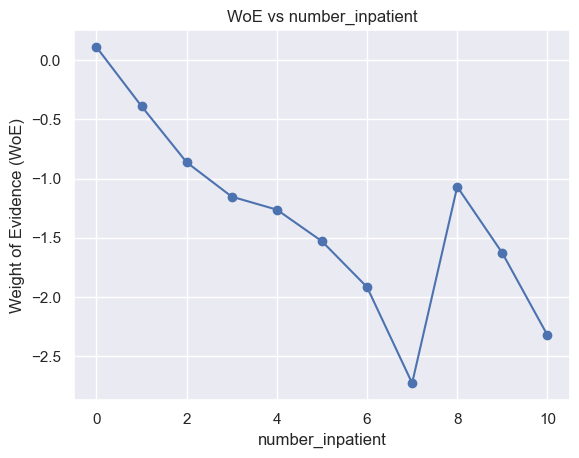

In [40]:
result = woe_discrete(X_train, y_train, 'number_inpatient')

result_sorted = result.copy()
result_sorted['number_inpatient'] = result_sorted['number_inpatient'].astype(float)
result_sorted = result_sorted.sort_values('number_inpatient')

plt.plot(result_sorted['number_inpatient'], result_sorted['WoE'], marker='o')
plt.xlabel('number_inpatient')
plt.ylabel('Weight of Evidence (WoE)')
plt.title('WoE vs number_inpatient')
plt.show()  

## can see that 8,9,10 show volatile. This is due to small sample that caused the random noise!! 

In [41]:
X_train['number_inpatient_clipped_7'] = X_train['number_inpatient'].clip(upper=7)

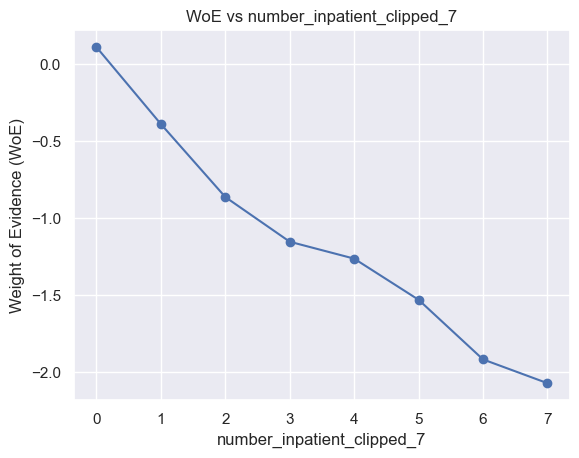

In [42]:
result = woe_discrete(X_train, y_train, 'number_inpatient_clipped_7')

result_sorted = result.copy()
result_sorted['number_inpatient_clipped_7'] = result_sorted['number_inpatient_clipped_7'].astype(float)
result_sorted = result_sorted.sort_values('number_inpatient_clipped_7')

plt.plot(result_sorted['number_inpatient_clipped_7'], result_sorted['WoE'], marker='o')
plt.xlabel('number_inpatient_clipped_7')
plt.ylabel('Weight of Evidence (WoE)')
plt.title('WoE vs number_inpatient_clipped_7')
plt.show()  

## can see that 8,9,10 show volatile. This is due to small sample that caused the random noise!! 

### Time in Hospital

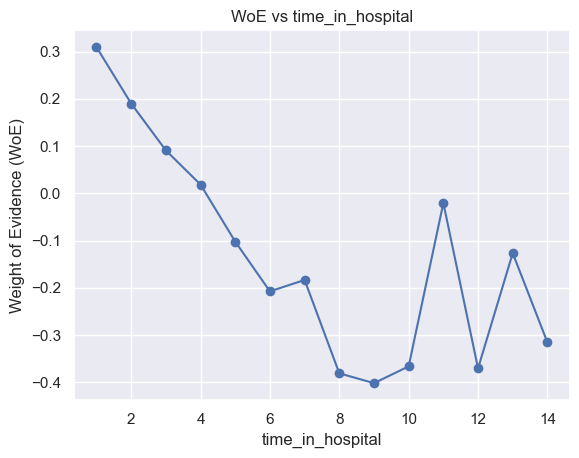

In [43]:
result = woe_discrete(X_train, y_train, 'time_in_hospital')

result_sorted = result.copy()
result_sorted['time_in_hospital'] = result_sorted['time_in_hospital'].astype(float)
result_sorted = result_sorted.sort_values('time_in_hospital')

plt.plot(result_sorted['time_in_hospital'], result_sorted['WoE'], marker='o')
plt.xlabel('time_in_hospital')
plt.ylabel('Weight of Evidence (WoE)')
plt.title('WoE vs time_in_hospital')
plt.show()  

In [44]:
def bin_time_in_hospital(x):
    if x >= 8:
        return 8      # small sample population from 8 onwards! should combine and clip to 8 max.
    else:
        return x

X_train['time_in_hospital_clipped_8'] = X_train['time_in_hospital'].apply(bin_time_in_hospital)

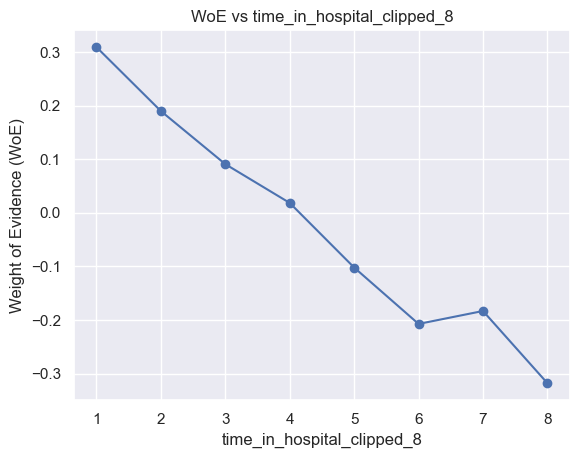

In [45]:
result = woe_discrete(X_train, y_train, 'time_in_hospital_clipped_8')

result_sorted = result.copy()
result_sorted['time_in_hospital_clipped_8'] = result_sorted['time_in_hospital_clipped_8'].astype(float)
result_sorted = result_sorted.sort_values('time_in_hospital_clipped_8')

plt.plot(result_sorted['time_in_hospital_clipped_8'], result_sorted['WoE'], marker='o')
plt.xlabel('time_in_hospital_clipped_8')
plt.ylabel('Weight of Evidence (WoE)')
plt.title('WoE vs time_in_hospital_clipped_8')
plt.show()  

### Number of Medications

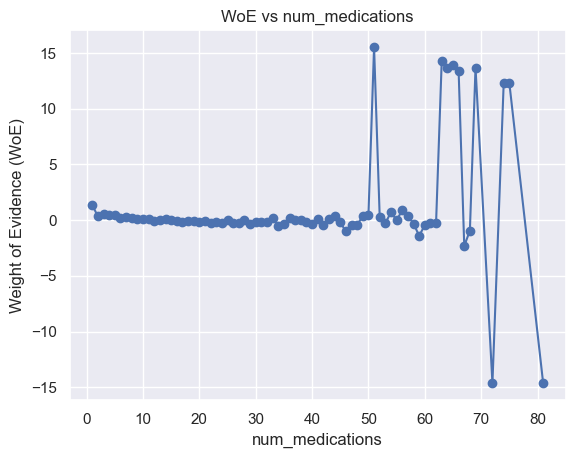

In [46]:
result = woe_discrete(X_train, y_train, 'num_medications')

result_sorted = result.copy()
result_sorted['num_medications'] = result_sorted['num_medications'].astype(float)
result_sorted = result_sorted.sort_values('num_medications')

plt.plot(result_sorted['num_medications'], result_sorted['WoE'], marker='o')
plt.xlabel('num_medications')
plt.ylabel('Weight of Evidence (WoE)')
plt.title('WoE vs num_medications')
plt.show()  

In [47]:
def bin_num_medications(x):
    if x <= 5:
        return '1-5'
    elif x <= 10:
        return '6-10'
    elif x <= 15:
        return '11-15'
    elif x <= 25:
        return '16-25'
    elif x <= 30:
        return '26-30'
    else:
        return '31+'

X_train['num_medications_coarse'] = X_train['num_medications'].apply(bin_num_medications)

In [48]:
woe_med = woe_discrete(X_train, y_train, 'num_medications_coarse')

order = ['1-5', '6-10', '11-15', '16-25', '26-30', '31+']

woe_med['num_medications_coarse'] = pd.Categorical(
    woe_med['num_medications_coarse'],
    categories=order,
    ordered=True
)

woe_med = woe_med.sort_values('num_medications_coarse')

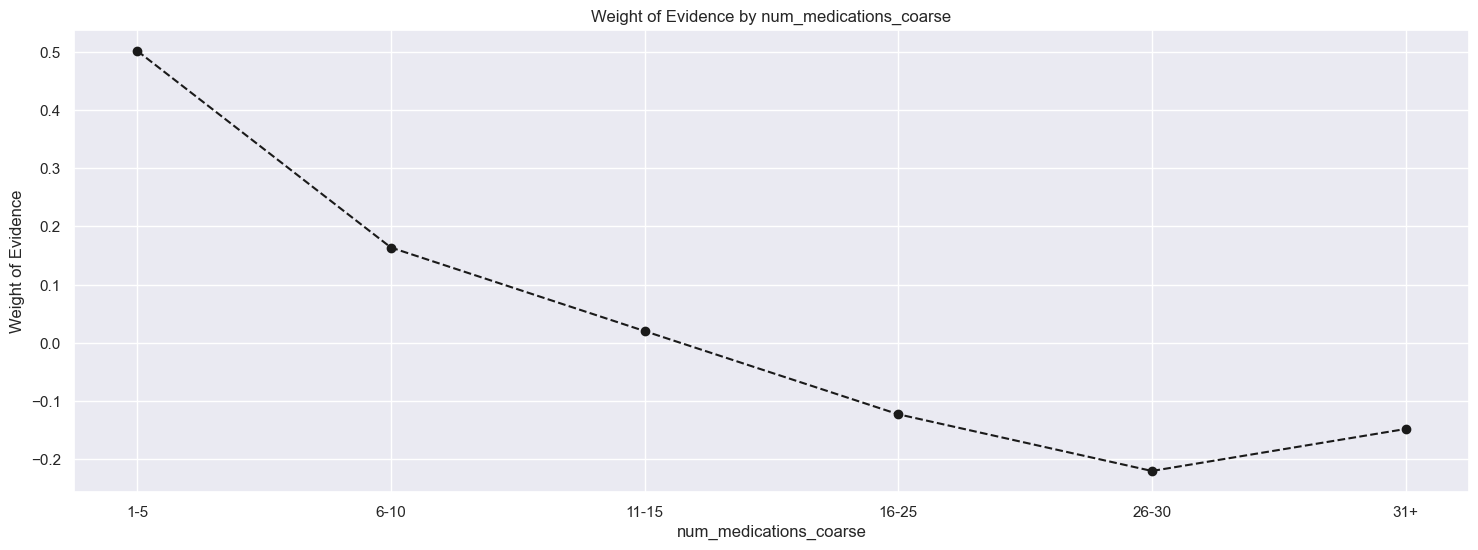

In [49]:
plot_by_woe(woe_med)  # dont force monotonicity, this may be really happening, highest meds maybe the most supervision.

### Number of Diagnoses

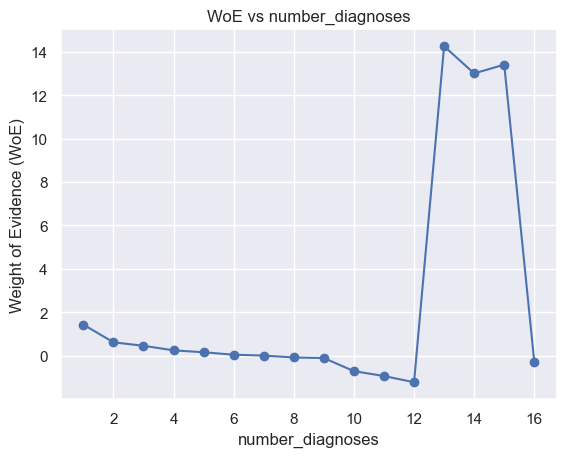

In [50]:
result = woe_discrete(X_train, y_train, 'number_diagnoses')

result_sorted = result.copy()
result_sorted['number_diagnoses'] = result_sorted['number_diagnoses'].astype(float)
result_sorted = result_sorted.sort_values('number_diagnoses')

plt.plot(result_sorted['number_diagnoses'], result_sorted['WoE'], marker='o')
plt.xlabel('number_diagnoses')
plt.ylabel('Weight of Evidence (WoE)')
plt.title('WoE vs number_diagnoses')
plt.show()   # SMALL SAMPLE SIZE from 10 onwards, random noise!!!!!

In [51]:
X_train['number_diagnoses_clipped_10'] = np.where(X_train['number_diagnoses'] >= 10, 10, X_train['number_diagnoses'])

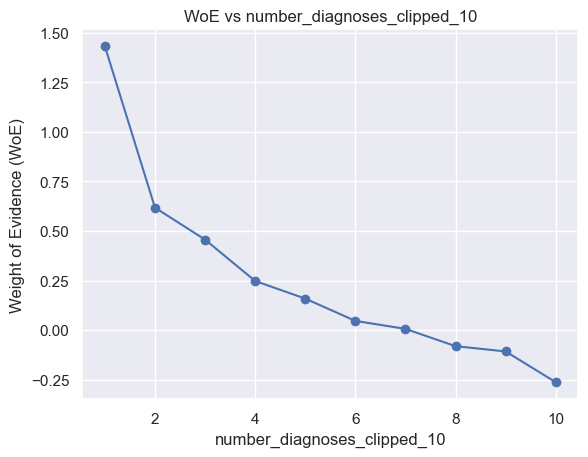

In [52]:
result = woe_discrete(X_train, y_train, 'number_diagnoses_clipped_10')

result_sorted = result.copy()
result_sorted['number_diagnoses_clipped_10'] = result_sorted['number_diagnoses_clipped_10'].astype(float)
result_sorted = result_sorted.sort_values('number_diagnoses_clipped_10')

plt.plot(result_sorted['number_diagnoses_clipped_10'], result_sorted['WoE'], marker='o')
plt.xlabel('number_diagnoses_clipped_10')
plt.ylabel('Weight of Evidence (WoE)')
plt.title('WoE vs number_diagnoses_clipped_10')
plt.show()  

### Total number of procedures

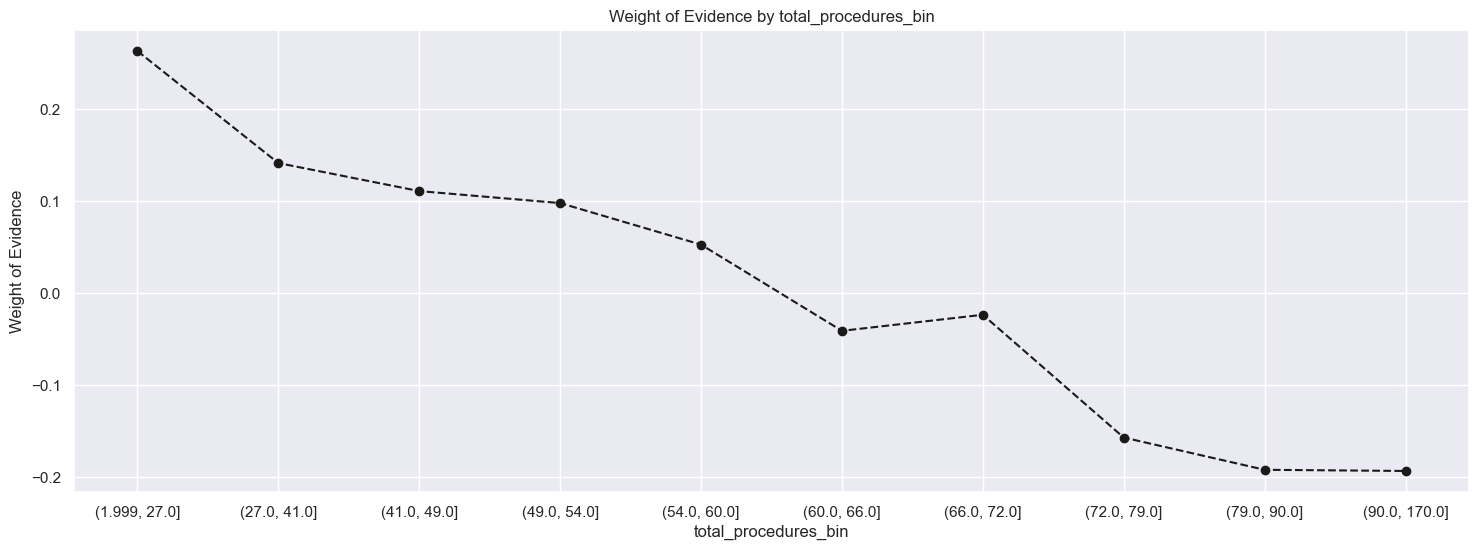

In [53]:
plot_by_woe(woe_discrete(X_train, y_train, 'total_procedures_bin'))

### Final X_Train

In [55]:
chosen = ['age_encoded', 'discharge_disposition_category_hospital / facility', 'number_inpatient_clipped_7', 
          'time_in_hospital_clipped_8', 'num_medications_coarse', 'number_diagnoses_clipped_10', 'total_procedures_bin']

In [57]:
X_train = X_train[chosen]

In [75]:
cat_order = ['1-5', '6-10', '11-15', '16-25', '26-30', '31+']

X_train['num_medications_ord'] = pd.Categorical(
    X_train['num_medications_coarse'],
    categories=cat_order,
    ordered=True
).codes

In [70]:
X_train['total_procedures_ord'] = X_train['total_procedures_bin'].cat.codes

In [58]:
# Apply same transformation of Training onto Test

In [59]:
age_order = [
    '[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
    '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)'
]

# Create a mapping dictionary: bin → ordinal number
age_mapping = {age: i+1 for i, age in enumerate(age_order)}

# Apply the mapping
X_test['age_encoded'] = X_test['age'].map(age_mapping)

In [60]:
X_test = pd.get_dummies(X_test, columns=['discharge_disposition_category'], drop_first=True)
X_test.drop(columns = ['discharge_disposition_category_inpatient', 
                   'discharge_disposition_category_outpatient',
                   'discharge_disposition_category_hospice',
                   'discharge_disposition_category_other'],
                   axis = 1, inplace = True)

In [61]:
X_test['number_inpatient_clipped_7'] = X_test['number_inpatient'].clip(upper=7)

In [62]:
X_test['time_in_hospital_clipped_8'] = X_test['time_in_hospital'].clip(upper=8)

In [63]:
def bin_num_medications(x):
    if x <= 5:
        return '1-5'
    elif x <= 10:
        return '6-10'
    elif x <= 15:
        return '11-15'
    elif x <= 25:
        return '16-25'
    elif x <= 30:
        return '26-30'
    else:
        return '31+'

X_test['num_medications_coarse'] = X_test['num_medications'].apply(bin_num_medications)

In [64]:
X_test['number_diagnoses_clipped_10'] = X_test['number_diagnoses'].clip(upper=10)

In [67]:
bins = [i.left for i in X_train['total_procedures_bin'].cat.categories] + [X_train['total_procedures_bin'].cat.categories[-1].right]
X_test['total_procedures_bin'] = pd.cut(X_test['total_procedures'], bins=bins, include_lowest=True)

In [71]:
X_test['total_procedures_ord'] = X_test['total_procedures_bin'].cat.codes

In [77]:
cat_order = ['1-5', '6-10', '11-15', '16-25', '26-30', '31+']

X_test['num_medications_ord'] = pd.Categorical(
    X_test['num_medications_coarse'],
    categories=cat_order,
    ordered=True
).codes

#### end

In [79]:
X_train.drop(columns = ['num_medications_coarse', 'total_procedures_bin'], axis = 1, inplace = True)

In [80]:
X_train

,age_encoded,discharge_disposition_category_hospital / facility,number_inpatient_clipped_7,time_in_hospital_clipped_8,number_diagnoses_clipped_10,total_procedures_ord,num_medications_ord
15796,8,False,0,2,8,4,1
91253,4,False,0,2,3,5,0
3377,8,True,0,5,9,7,3
16822,7,False,0,8,7,9,5
57752,7,False,0,3,6,5,4
...,...,...,...,...,...,...,...
819,5,False,0,2,3,3,3
31852,5,False,0,5,5,7,2
92538,7,False,0,8,9,9,5
45895,8,False,0,1,9,1,2


In [84]:
X_test = X_test[['age_encoded', 'discharge_disposition_category_hospital / facility' , 'number_inpatient_clipped_7', 'time_in_hospital_clipped_8', 'number_diagnoses_clipped_10',
                 'total_procedures_ord' ,'num_medications_ord']]

In [89]:
X_train = X_train.astype({col: int for col in X_train.select_dtypes(bool).columns})
X_test  = X_test.astype({col: int for col in X_test.select_dtypes(bool).columns})

In [96]:
X_train

,age_encoded,discharge_disposition_category_hospital / facility,number_inpatient_clipped_7,time_in_hospital_clipped_8,number_diagnoses_clipped_10,total_procedures_ord,num_medications_ord
15796,8,0,0,2,8,4,1
91253,4,0,0,2,3,5,0
3377,8,1,0,5,9,7,3
16822,7,0,0,8,7,9,5
57752,7,0,0,3,6,5,4
...,...,...,...,...,...,...,...
819,5,0,0,2,3,3,3
31852,5,0,0,5,5,7,2
92538,7,0,0,8,9,9,5
45895,8,0,0,1,9,1,2


In [90]:
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train)
X_test_const  = sm.add_constant(X_test)

logit_model = sm.Logit(y_train, X_train_const)
result = logit_model.fit(disp=False)

In [91]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:      readmitted_binary   No. Observations:                49301
Model:                          Logit   Df Residuals:                    49293
Method:                           MLE   Df Model:                            7
Date:                Sat, 18 Oct 2025   Pseudo R-squ.:                 0.02848
Time:                        19:28:58   Log-Likelihood:                -14418.
converged:                       True   LL-Null:                       -14841.
Covariance Type:            nonrobust   LLR p-value:                3.069e-178
                                                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------
const                                                 -3.2096      0.094    -34.032      0.000      -3.394      -3.025
age_encoded

In [92]:
y_pred_prob = result.predict(X_test_const)

In [93]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

print("AUC:", roc_auc_score(y_test, y_pred_prob))

AUC: 0.6263048703709576


In [94]:
y_pred_prob = result.predict(X_train_const)

In [95]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

print("AUC:", roc_auc_score(y_train, y_pred_prob))

AUC: 0.6270734589128372


In [97]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(X_train_const.values, i)
              for i in range(X_train_const.shape[1])]
vif["variable"] = X_train_const.columns
print(vif)

         VIF                                           variable
0  29.558759                                              const
1   1.142154                                        age_encoded
2   1.122178  discharge_disposition_category_hospital / faci...
3   1.010091                         number_inpatient_clipped_7
4   1.437534                         time_in_hospital_clipped_8
5   1.179426                        number_diagnoses_clipped_10
6   1.526154                               total_procedures_ord
7   1.557973                                num_medications_ord


#### Drop the highly statistically insignificant 'total_procedures_ord' variable

In [98]:
X_train.drop(['total_procedures_ord'], axis = 1, inplace = True)

In [99]:
X_test.drop(['total_procedures_ord'], axis = 1, inplace = True)

In [100]:
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train)
X_test_const  = sm.add_constant(X_test)

logit_model = sm.Logit(y_train, X_train_const)
result = logit_model.fit(disp=False)

In [101]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:      readmitted_binary   No. Observations:                49301
Model:                          Logit   Df Residuals:                    49294
Method:                           MLE   Df Model:                            6
Date:                Sat, 18 Oct 2025   Pseudo R-squ.:                 0.02842
Time:                        19:42:46   Log-Likelihood:                -14419.
converged:                       True   LL-Null:                       -14841.
Covariance Type:            nonrobust   LLR p-value:                5.518e-179
                                                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------
const                                                 -3.2046      0.094    -33.985      0.000      -3.389      -3.020
age_encoded

In [106]:
y_pred_prob = result.predict(X_train_const)

In [107]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

print("Training AUC:", roc_auc_score(y_train, y_pred_prob))

Training AUC: 0.6266359159835055


In [108]:
y_pred_prob = result.predict(X_test_const)

In [109]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

print("Testing AUC:", roc_auc_score(y_test, y_pred_prob))

Testing AUC: 0.6256393670757295


In [110]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(X_train_const.values, i)
              for i in range(X_train_const.shape[1])]
vif["variable"] = X_train_const.columns
print(vif)

         VIF                                           variable
0  29.457448                                              const
1   1.140420                                        age_encoded
2   1.121845  discharge_disposition_category_hospital / faci...
3   1.007310                         number_inpatient_clipped_7
4   1.329758                         time_in_hospital_clipped_8
5   1.173675                        number_diagnoses_clipped_10
6   1.321919                                num_medications_ord
